In [ ]:
!pip install neptune
!pip install neptune
!pip install numpy
!pip install scikit-learn
!pip install alpha_vantage
!pip install matplotlib
!pip install pandas
!pip install neptune-tensorflow-keras

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 kB 1.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 502.6/502.6 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.6/139.6 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.4/13.4 MB 98.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.4/84.4 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.4/66.4 kB 5.5 MB/s eta 0:00:00
  Created wheel for bravado-core: filename=bravado_core-6.1.1-py2.py3-none-any.whl size=67675 sha256=6c40afb99c77e8d392cbac747edb4f7dc7dd55e62a7a0561b7d24635f08a196a
  Stored in directory: /root/.cache/pip/wheels/cf/d7/1c/1d707a21e0a0323bdbfbb2f6de125ae6bb70d62aa2838df321
Successfully built bravado-core


**Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import neptune
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM
from alpha_vantage.timeseries import TimeSeries


**Load closing prices from Alpha_Vantage**

In [ ]:
# get data from alpha_vantage as csv
STOCK = "AAPL"
KEY =  "BPBSUICJ7AGJ53KW"
ts = TimeSeries(key=KEY, output_format='pandas')
data, meta_data = ts.get_daily(symbol=STOCK, outputsize='full')

data = data.rename(columns=lambda col: "Close" if "close" in col.lower() else col)
data.to_csv("stock_market_data-AAPL.csv")

#print columns and first 5 datapoints
print(data.head())




            1. open   2. high  3. low   Close   5. volume
date                                                     
2025-03-26   223.51  225.0200  220.47  221.53  34389225.0
2025-03-25   220.77  224.1000  220.08  223.75  34493583.0
2025-03-24   221.00  221.4800  218.58  220.73  44299483.0
2025-03-21   211.56  218.8400  211.28  218.27  94127768.0
2025-03-20   213.99  217.4899  212.22  214.10  48862947.0


**Process data for train and test split**

In [ ]:
stockprices = pd.read_csv("stock_market_data-AAPL.csv", index_col="date")

test_ratio = 0.2
training_ratio = 1 - test_ratio

train_size = int(training_ratio * len(stockprices))
test_size = int(test_ratio * len(stockprices))
print(f"train_size: {train_size}")
print(f"test_size: {test_size}")

train = stockprices[:train_size][["Close"]]
test = stockprices[train_size:][["Close"]]

train_size: 5111
test_size: 1277


**Functions for data processing, performance metrics, visualization**

In [ ]:
def extract_seqX_outcomeY(data, N, offset):
    """
    Split time-series into training sequence X and outcome value Y
    Args:
        data - dataset
        N - window size, e.g., 50 for 50 days of historical stock prices
        offset - position to start the split
    """
    X, y = [], []

    for i in range(offset, len(data)):
        X.append(data[i - N : i])
        y.append(data[i])

    return np.array(X), np.array(y)


def calculate_rmse(y_true, y_pred):
    """
    Calculate the Root Mean Squared Error (RMSE)
    """
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    return rmse


def calculate_mape(y_true, y_pred):
    """
    Calculate the Mean Absolute Percentage Error (MAPE) %
    """
    y_pred, y_true = np.array(y_pred), np.array(y_true)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return mape

def calculate_perf_metrics(var):
    #RMSE
    rmse = calculate_rmse(
        np.array(stockprices[train_size:]["Close"]),
        np.array(stockprices[train_size:][var]),
    )
    #MAPE
    mape = calculate_mape(
        np.array(stockprices[train_size:]["Close"]),
        np.array(stockprices[train_size:][var]),
    )

    #Log to Neptune
    run["RMSE"] = rmse
    run["MAPE (%)"] = mape

    return rmse, mape

def plot_stock_trend(var, cur_title, stockprices=stockprices):
    ax = stockprices[["Close", var, "200day"]].plot(figsize=(20, 10))
    plt.grid(False)
    plt.title(cur_title)
    plt.axis("tight")
    plt.ylabel("Stock Price ($)")

    #Log to Neptune
    run["Plot of Stock Predictions"].upload(
        neptune.types.File.as_image(ax.get_figure())
    )

**Show Baseline performance with SMA/EMA**

[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/stockvisionai/lstm/e/LSTM-19
[neptune] [info   ] Shutting down background jobs, please wait a moment...
[neptune] [info   ] Done!
[neptune] [info   ] Waiting for the remaining 3 operations to synchronize with Neptune. Do not kill this process.
[neptune] [info   ] All 3 operations synced, thanks for waiting!
[neptune] [info   ] Explore the metadata in the Neptune app: https://app.neptune.ai/stockvisionai/lstm/e/LSTM-19/metadata


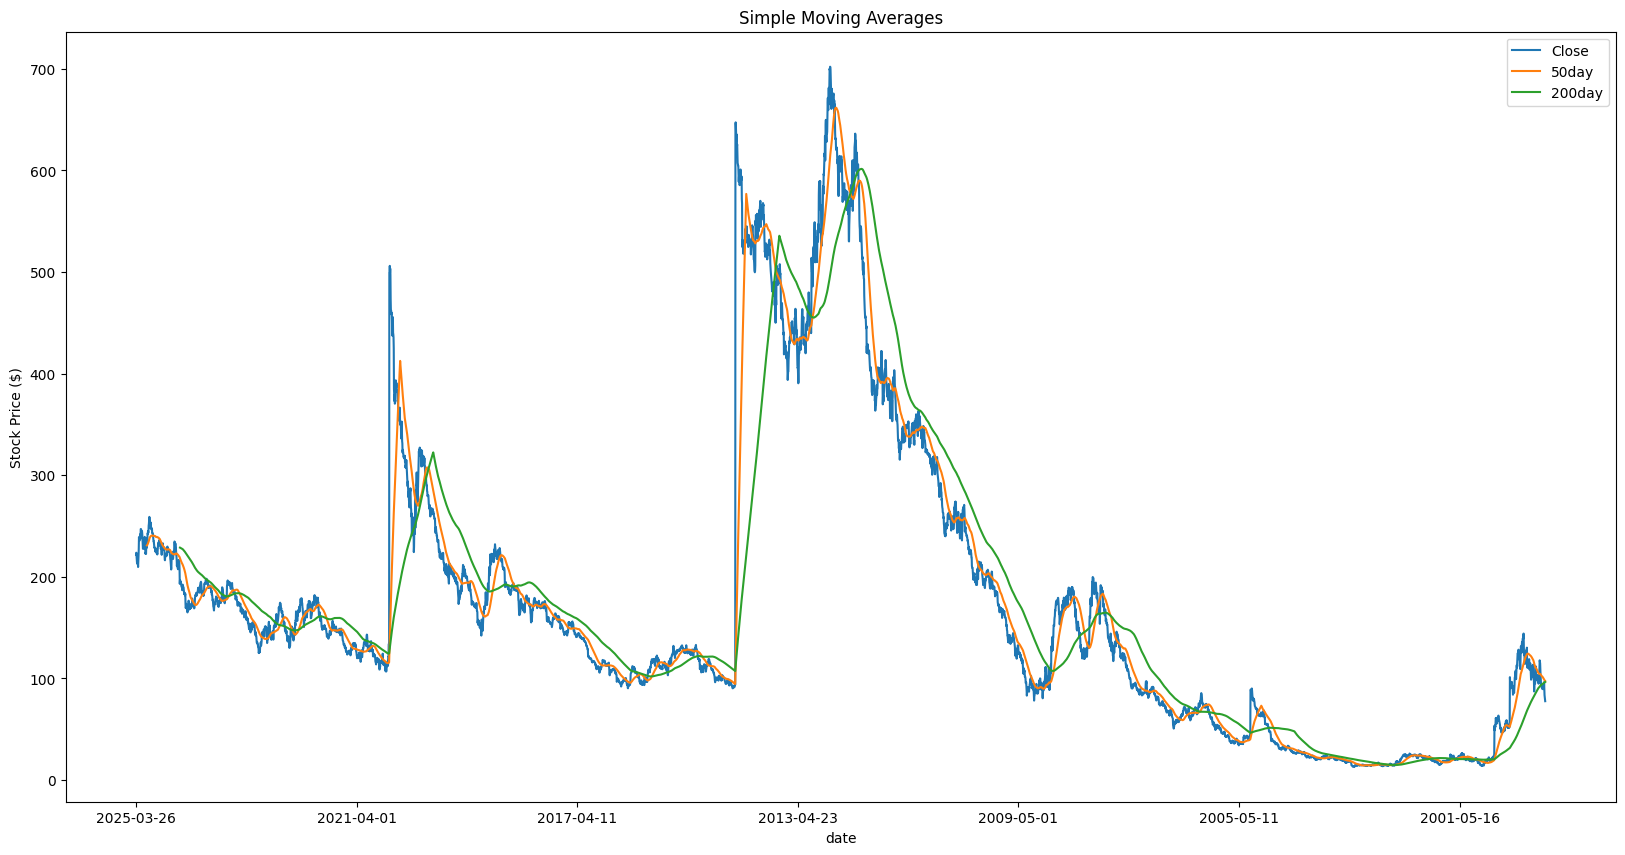

In [ ]:
window_size = 50

# Initialize a Neptune run
run = neptune.init_run(
        project="stockvisionai/lstm",
        api_token="eyJhcGlfYWRkcmVzcyI6Imh0dHBzOi8vYXBwLm5lcHR1bmUuYWkiLCJhcGlfdXJsIjoiaHR0cHM6Ly9hcHAubmVwdHVuZS5haSIsImFwaV9rZXkiOiI1MDhmOTcwNC1iNzBjLTQ5ODQtOTNhNy1kYWFmYWQzNTViZDcifQ==",
        name="SMA",
        description="stock-prediction-machine-learning",
        tags=["stockprediction", "MA_Simple", "neptune"]
  )

window_var = f"{window_size}day"

stockprices[window_var] = stockprices["Close"].rolling(window_size).mean()

### Include a 200-day SMA for reference
stockprices["200day"] = stockprices["Close"].rolling(200).mean()

### Plot and performance metrics for SMA model
plot_stock_trend(var=window_var, cur_title="Simple Moving Averages")
rmse_sma, mape_sma = calculate_perf_metrics(var=window_var)

### Stop the run
run.stop()

[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/stockvisionai/lstm/e/LSTM-20
[neptune] [info   ] Shutting down background jobs, please wait a moment...
[neptune] [info   ] Done!
[neptune] [info   ] Waiting for the remaining 3 operations to synchronize with Neptune. Do not kill this process.
[neptune] [info   ] All 3 operations synced, thanks for waiting!
[neptune] [info   ] Explore the metadata in the Neptune app: https://app.neptune.ai/stockvisionai/lstm/e/LSTM-20/metadata


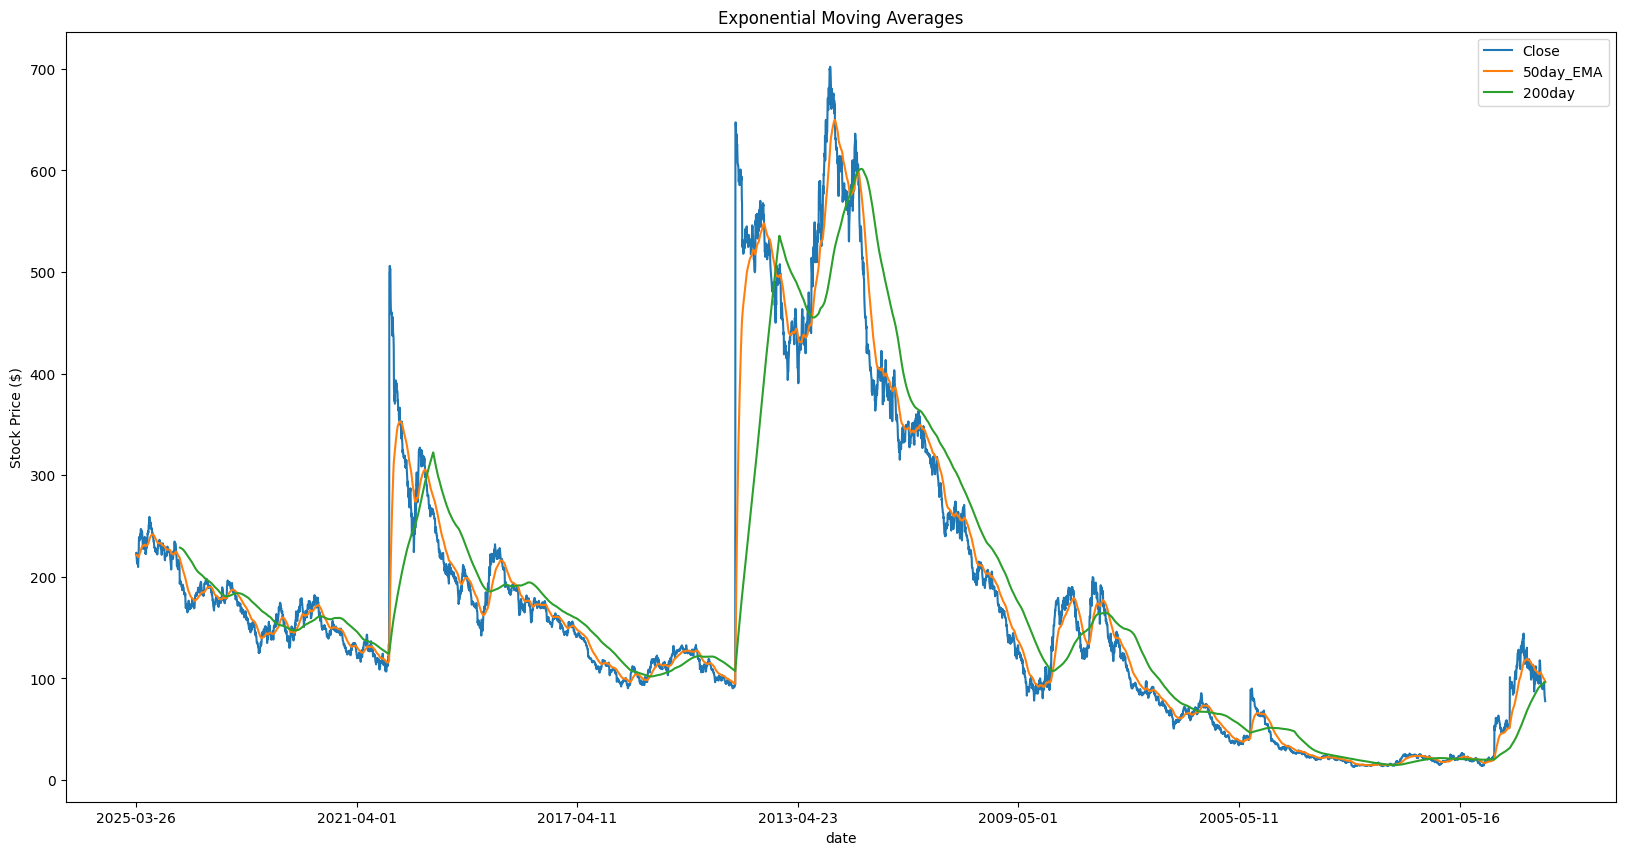

In [ ]:
# Initialize a Neptune run

run = neptune.init_run(
        project="stockvisionai/lstm",
        api_token="eyJhcGlfYWRkcmVzcyI6Imh0dHBzOi8vYXBwLm5lcHR1bmUuYWkiLCJhcGlfdXJsIjoiaHR0cHM6Ly9hcHAubmVwdHVuZS5haSIsImFwaV9rZXkiOiI1MDhmOTcwNC1iNzBjLTQ5ODQtOTNhNy1kYWFmYWQzNTViZDcifQ==",
        name="EMA",
        description="stock-prediction-machine-learning",
        tags=["stockprediction", "EMA", "neptune"]
  )

###### Exponential MA
window_ema_var = f"{window_var}_EMA"

# Calculate the 50-day exponentially weighted moving average
stockprices[window_ema_var] = (
    stockprices["Close"].ewm(span=window_size, adjust=False).mean()
)
stockprices["200day"] = stockprices["Close"].rolling(200).mean()

### Plot and performance metrics for EMA model
plot_stock_trend(
    var=window_ema_var, cur_title="Exponential Moving Averages")
rmse_ema, mape_ema = calculate_perf_metrics(var=window_ema_var)

### Stop the run
run.stop()

In [ ]:
layer_units = 50
optimizer = "adam"
cur_epochs = 15
cur_batch_size = 20

cur_LSTM_args = {
    "units": layer_units,
    "optimizer": optimizer,
    "batch_size": cur_batch_size,
    "epochs": cur_epochs,
}

# Initialize a Neptune run
run = neptune.init_run(
        project="stockvisionai/lstm",
        api_token="eyJhcGlfYWRkcmVzcyI6Imh0dHBzOi8vYXBwLm5lcHR1bmUuYWkiLCJhcGlfdXJsIjoiaHR0cHM6Ly9hcHAubmVwdHVuZS5haSIsImFwaV9rZXkiOiI1MDhmOTcwNC1iNzBjLTQ5ODQtOTNhNy1kYWFmYWQzNTViZDcifQ==",
        name="LSTM",
        description="stock-prediction-machine-learning",
        tags=["stockprediction", "LSTM", "neptune"]
  )
run["LSTM_args"] = cur_LSTM_args

[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/stockvisionai/lstm/e/LSTM-21


In [ ]:
# Scale our dataset
scaler = StandardScaler()
scaled_data = scaler.fit_transform(stockprices[["Close"]])
scaled_data_train = scaled_data[: train.shape[0]]
print(scaler)
# We use past 50 days’ stock prices for our training to predict the 51th day's closing price.
X_train, y_train = extract_seqX_outcomeY(scaled_data_train, window_size, window_size)

NameError: name 'StandardScaler' is not defined

In [ ]:
### Setup Neptune's Keras integration ###
from neptune.integrations.tensorflow_keras import NeptuneCallback

neptune_callback = NeptuneCallback(run=run)

### Build a LSTM model and log training progress to Neptune ###

def Run_LSTM(X_train, layer_units=50):
    inp = Input(shape=(X_train.shape[1], 1))

    x = LSTM(units=layer_units, return_sequences=True)(inp)
    x = LSTM(units=layer_units)(x)
    out = Dense(1, activation="linear")(x)
    model = Model(inp, out)

    # Compile the LSTM neural net
    model.compile(loss="mean_squared_error", optimizer="adam")

    return model


model = Run_LSTM(X_train, layer_units=layer_units)

history = model.fit(
    X_train,
    y_train,
    epochs=cur_epochs,
    batch_size=cur_batch_size,
    verbose=1,
    validation_split=0.1,
    shuffle=True,
    callbacks=[neptune_callback],
)

Epoch 1/15
228/228 ━━━━━━━━━━━━━━━━━━━━ 13s 39ms/step - loss: 0.1306 - val_loss: 0.0051
Epoch 2/15
228/228 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - loss: 0.0153 - val_loss: 0.0105
Epoch 3/15
228/228 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - loss: 0.0147 - val_loss: 8.5855e-04
Epoch 4/15
228/228 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - loss: 0.0062 - val_loss: 8.7025e-04
Epoch 5/15
228/228 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - loss: 0.0117 - val_loss: 9.3157e-04
Epoch 6/15
228/228 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - loss: 0.0061 - val_loss: 0.0022
Epoch 7/15
228/228 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - loss: 0.0032 - val_loss: 0.0053
Epoch 8/15
228/228 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - loss: 0.0032 - val_loss: 0.0015
Epoch 9/15
228/228 ━━━━━━━━━━━━━━━━━━━━ 11s 37ms/step - loss: 0.0069 - val_loss: 0.0020
Epoch 10/15
228/228 ━━━━━━━━━━━━━━━━━━━━ 11s 42ms/step - loss: 0.0024 - val_loss: 0.0055
Epoch 11/15
228/228 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step - loss: 0.0054 - val_loss: 5.7099e-04
Epoch 12/15
228/22

In [ ]:
# predict stock prices using past window_size stock prices
def preprocess_testdat(data=stockprices, scaler=scaler, window_size=window_size, test=test):
    raw = data["Close"][len(data) - len(test) - window_size:].values
    raw = raw.reshape(-1,1)
    raw = scaler.transform(raw)

    X_test = [raw[i-window_size:i, 0] for i in range(window_size, raw.shape[0])]
    X_test = np.array(X_test)

    X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
    return X_test

X_test = preprocess_testdat()

predicted_price_ = model.predict(X_test)
predicted_price = scaler.inverse_transform(predicted_price_)

# Plot predicted price vs actual closing price
test["Predictions_lstm"] = predicted_price

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step


[neptune] [info   ] Shutting down background jobs, please wait a moment...
[neptune] [info   ] Done!
[neptune] [info   ] Waiting for the remaining 1 operations to synchronize with Neptune. Do not kill this process.
[neptune] [info   ] All 1 operations synced, thanks for waiting!
[neptune] [info   ] Explore the metadata in the Neptune app: https://app.neptune.ai/stockvisionai/lstm/e/LSTM-21/metadata


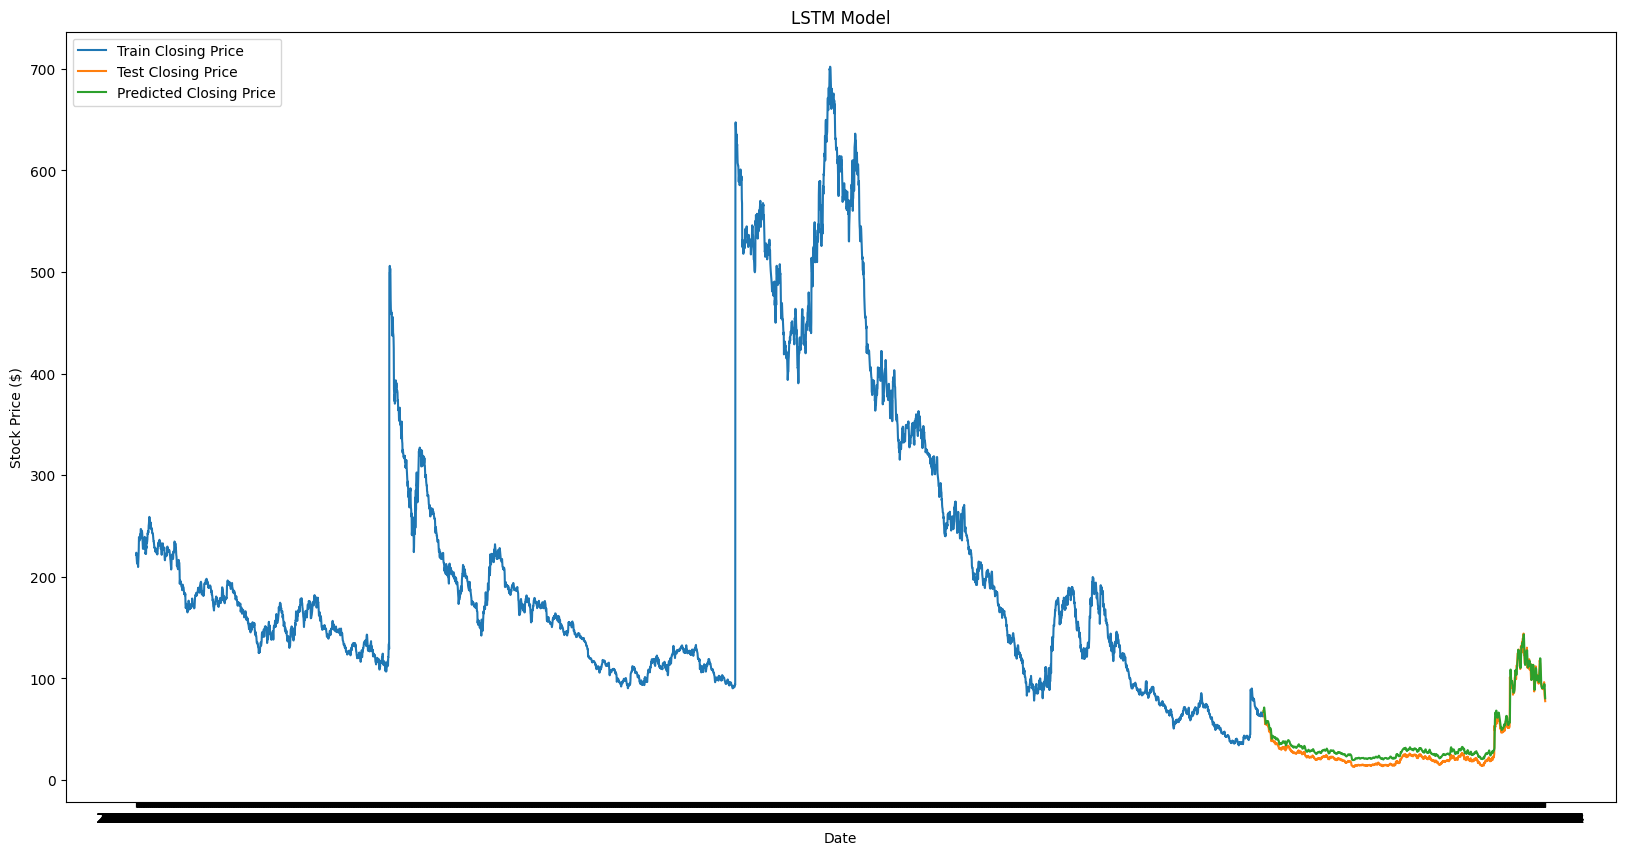

In [ ]:
# Evaluate performance
rmse_lstm = calculate_rmse(np.array(test["Close"]), np.array(test["Predictions_lstm"]))
mape_lstm = calculate_mape(np.array(test["Close"]), np.array(test["Predictions_lstm"]))

### Log to Neptune
run["RMSE"] = rmse_lstm
run["MAPE (%)"] = mape_lstm

### Plot prediction and true trends and log to Neptune
def plot_stock_trend_lstm(train, test):
    fig = plt.figure(figsize = (20,10))
    plt.plot(np.asarray(train.index), np.asarray(train["Close"]), label = "Train Closing Price")
    plt.plot(np.asarray(test.index), np.asarray(test["Close"]), label = "Test Closing Price")
    plt.plot(np.asarray(test.index), np.asarray(test["Predictions_lstm"]), label = "Predicted Closing Price")
    plt.title("LSTM Model")
    plt.xlabel("Date")
    plt.ylabel("Stock Price ($)")
    plt.legend(loc="upper left")

    ## Log image to Neptune
    run["Plot of Stock Predictions"].upload(neptune.types.File.as_image(fig))

plot_stock_trend_lstm(train, test)

### Stop the run after logging
run.stop()

In [ ]:
from google.colab import files

model.save("lstm_model.h5")
files.download("lstm_model.h5")

# use model = tf.keras.models.load_model("lstm_model.h5") to load model locally


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>